In [2]:
import os
import sys
from google.colab import drive

PROJECT_REL_PATH = 'COMP411/assignments/COMP-411_Project/chessvision/notebooks'
MOUNT_POINT = '/content/drive'

def setup_environment():
    # 1. Mount Drive if not already mounted
    if not os.path.exists(MOUNT_POINT):
        print("Mounting Google Drive...")
        drive.mount(MOUNT_POINT)
    else:
        print("Drive already mounted.")

    full_path = os.path.join(MOUNT_POINT, 'MyDrive', PROJECT_REL_PATH)

    # 2. Navigate to the directory
    try:
        os.chdir(full_path)
        if full_path not in sys.path:
            sys.path.append(full_path)

    except FileNotFoundError:
        print(f"ERROR: Path not found: {full_path}")

# Run the setup
setup_environment()

Drive already mounted.


# Chess Vision Pipeline: UNet + YOLO → FEN Generation

## YOLO Model Performance Metrics

**Training Artifacts Location:**
- `models/yolov8_trained/chess_yolo_run/results.csv`
- `models/yolov8_trained/chess_yolo_run/results.png`
- `models/yolov8_trained/chess_yolo_run/confusion_matrix.png`
- `models/yolov8_trained/chess_yolo_run/BoxPR_curve.png`
- `models/yolov8_trained/chess_yolo_run/BoxF1_curve.png`

**Final Epoch (20) Metrics:**
- **Precision:** 98.74%
- **Recall:** 98.74%
- **mAP50:** 98.48%
- **mAP50-95:** 77.07%

## How to Run Demo

### Option 1: Batch Mode (Recommended for Demo)
1. **Configure paths** in the CONFIG section (Cell 2):
   - Set `BATCH_MODE = True`
   - Update `INPUT_FOLDER` to point to your test images folder (20-30 images recommended)
   - `OUTPUT_FOLDER` will be created automatically at `demo_outputs/`

2. **Run all cells** in order (Cells 0, 1, 2)

3. **Check outputs:**
   - Overlay images: `demo_outputs/*_overlay.jpg`
   - Results CSV: `demo_outputs/demo_results.csv`

### Option 2: Single Image Mode
1. **Configure paths** in the CONFIG section:
   - Set `BATCH_MODE = False`
   - Update `TEST_IMG_PATH` to point to a single test image

2. **Run all cells** - results will be displayed inline

### Notes
- Models are loaded once and reused for batch processing (faster)
- All paths are auto-detected (works in Colab and locally)
- Errors are caught and logged in the CSV for debugging

In [ ]:
!pip install ultralytics
!pip install segmentation_models_pytorch
!apt-get install stockfish
!pip install python-chess

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.2 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Suggested packages:
  polyglot xboard | scid
The following NEW packages will be installed:
  stockfish
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 24.8 MB of archives.
After this operation, 47.4 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 stockfish amd64 14.1-1 [24.8 MB]
Fetched 24.8 MB in 1s (23.1 MB/s)
Selecting previously unselected package stockfish.
(Reading database ... 121689 files and directories currently installed.)
Preparing to unpack .../stockfish_14.1-1_amd64.deb ...
Unpacking stockfish (14.1-1) ...
Setting up stockfish (14.1-1) ...
Processing triggers for man-db (2.10.2-1) ...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 8

In [4]:
import chess
import chess.engine
import os
from pathlib import Path

# ==========================================
# CONFIGURATION
# ==========================================
# This must match the path from the previous step
STOCKFISH_PATH = Path('/content/drive/MyDrive/COMP411/assignments/COMP-411_Project/chessvision/models/stockfish')

# ==========================================
# TEST SCRIPT
# ==========================================
def test_stockfish():
    print(f"🔍 Testing Stockfish at: {STOCKFISH_PATH}")

    # 1. CHECK FILE EXISTENCE
    if not STOCKFISH_PATH.exists():
        print("❌ FAIL: File not found.")
        return

    # 2. CHECK PERMISSIONS
    if not os.access(STOCKFISH_PATH, os.X_OK):
        print("⚠️ WARNING: File exists but is not executable. Fixing permissions...")
        try:
            STOCKFISH_PATH.chmod(0o755)
            print("✅ Permissions fixed.")
        except Exception as e:
            print(f"❌ FAIL: Could not change permissions: {e}")
            return

    # 3. RUN ENGINE TEST
    print("🚀 Attempting to run engine...")
    try:
        # We copy it to /content/temp_sf to avoid Drive execution issues (common in Colab)
        temp_bin = Path("/content/temp_stockfish_test")
        if not temp_bin.exists():
            import shutil
            shutil.copy2(STOCKFISH_PATH, temp_bin)
            temp_bin.chmod(0o755)

        with chess.engine.SimpleEngine.popen_uci(str(temp_bin)) as engine:
            # Create a simple board
            board = chess.Board()

            # Analyze for 0.1 seconds
            result = engine.play(board, chess.engine.Limit(time=0.1))

            print(f"✅ SUCCESS! Engine is working.")
            print(f"   Best Move for starting position: {result.move}")

    except Exception as e:
        print(f"❌ FAIL: Engine crashed. Error details:")
        print(e)

# Run the test
test_stockfish()

🔍 Testing Stockfish at: /content/drive/MyDrive/COMP411/assignments/COMP-411_Project/chessvision/models/stockfish
🚀 Attempting to run engine...
✅ SUCCESS! Engine is working.
   Best Move for starting position: e2e4


⚙️ Running on: cuda
📁 Base directory: /content/drive/MyDrive/COMP411/assignments/COMP-411_Project/chessvision
📁 Input folder: /content/drive/MyDrive/COMP411/assignments/COMP-411_Project/chessvision/data/raw/Chess Pieces Detection Image Dataset/Board_coordinates/test/images
📁 Output folder: /content/drive/MyDrive/COMP411/assignments/COMP-411_Project/chessvision/demo_outputs
🔄 Batch mode: False
⚙️ Initializing Stockfish from: /content/drive/MyDrive/COMP411/assignments/COMP-411_Project/chessvision/models/stockfish
✅ Stockfish (Local Drive Copy) is ready.


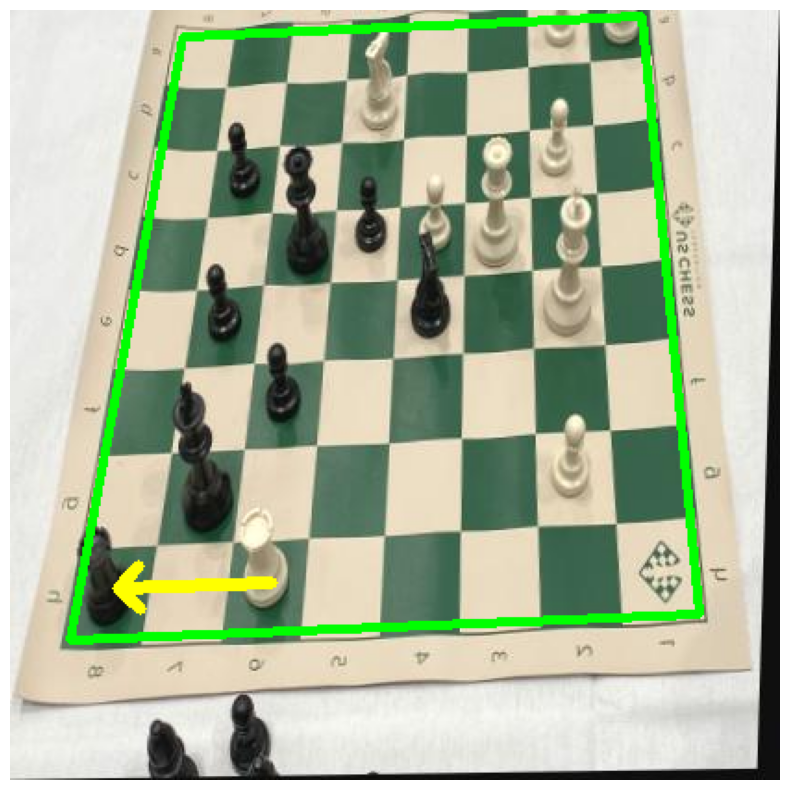

In [7]:
# ==========================================
# 0. INSTALL DEPENDENCIES
# ==========================================
import subprocess
import sys
import time
import csv
from datetime import datetime
import shutil
import os
def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

try:
    import segmentation_models_pytorch as smp
    import chess
    import chess.engine
except ImportError:
    print("📦 Installing libraries...")
    install("segmentation_models_pytorch")
    install("python-chess")
    print("✅ Installation Complete.")

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import chess
import requests
from torchvision import transforms
from ultralytics import YOLO
from pathlib import Path

# ==========================================
# 1. CONFIGURATION
# ==========================================
try:
    from google.colab import drive
    IN_COLAB = True
    BASE_DIR = Path('/content/drive/MyDrive/COMP411/assignments/COMP-411_Project/chessvision')
except ImportError:
    IN_COLAB = False
    possible_roots = [
        Path.cwd().parent,  # If running from notebooks/ directory
        Path.cwd(),         # If running from workspace root
    ]
    BASE_DIR = None
    for root in possible_roots:
        test_path = root / "models" / "best_yolov8.pt"
        if test_path.exists():
            BASE_DIR = root
            break
    if BASE_DIR is None:
        BASE_DIR = Path.cwd()

# Model paths
YOLO_PATH = BASE_DIR / 'models' / 'best_yolov8.pt'
UNET_PATH = BASE_DIR / 'models' / 'best_unet.pth'
STOCKFISH_DRIVE_PATH = BASE_DIR / 'models' / 'stockfish'

# Batch demo configuration
BATCH_MODE = False  # Set to False for single image mode
INPUT_FOLDER = BASE_DIR / 'data' / 'raw' / 'Chess Pieces Detection Image Dataset' / 'Board_coordinates' / 'test' / 'images'
OUTPUT_FOLDER = BASE_DIR / 'demo_outputs'
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

# Single image mode (used when BATCH_MODE = False)
TEST_IMG_PATH = BASE_DIR / 'data' / 'raw' / 'Chess Pieces Detection Image Dataset' / 'Chess Pieces.yolov8-obb' / 'train' / 'images' / '9d776e74e90c4f8092b060dd7567e2f8_jpg.rf.e56c4f14986b14ecae9d9693766bbb09.jpg'

# Pipeline parameters
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
UNET_INPUT_SIZE = 320
FOOT_CORRECTION = 0.85
BOARD_MARGIN = 0.02
YOLO_CONF_THRESHOLD = 0.25

print(f"⚙️ Running on: {DEVICE}")
print(f"📁 Base directory: {BASE_DIR}")
print(f"📁 Input folder: {INPUT_FOLDER}")
print(f"📁 Output folder: {OUTPUT_FOLDER}")
print(f"🔄 Batch mode: {BATCH_MODE}")

# ==========================================
# 2. ENGINE INITIALIZATION
# ==========================================
ACTIVE_ENGINE_PATH = None

def setup_stockfish():
    """
    Prepares the Stockfish binary exactly like the test script.
    Run this ONCE at the start.
    """
    global ACTIVE_ENGINE_PATH
    print(f"⚙️ Initializing Stockfish from: {STOCKFISH_DRIVE_PATH}")

    local_bin = Path("/content/stockfish_ready")

    if STOCKFISH_DRIVE_PATH.exists():
        try:
            os.chmod(STOCKFISH_DRIVE_PATH, 0o755)
        except:
            pass

        try:
            if local_bin.exists():
                os.remove(local_bin)
            shutil.copy2(STOCKFISH_DRIVE_PATH, local_bin)
            local_bin.chmod(0o755)

            try:
                engine = chess.engine.SimpleEngine.popen_uci(str(local_bin))
                engine.quit()
                print("✅ Stockfish (Local Drive Copy) is ready.")
                ACTIVE_ENGINE_PATH = local_bin
                return
            except Exception as e:
                print(f"⚠️ Copied binary failed to run: {e}")
        except Exception as e:
            print(f"⚠️ Failed to copy from Drive: {e}")

    if Path("/usr/games/stockfish").exists():
        print("✅ Using System Stockfish (Fallback).")
        ACTIVE_ENGINE_PATH = Path("/usr/games/stockfish")
    else:
        print("❌ CRITICAL: No working Stockfish found.")

setup_stockfish()

# ==========================================
# 3. GEOMETRY & HELPERS
# ==========================================
def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]; rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]; rect[3] = pts[np.argmax(diff)]
    return rect

def warp_chessboard(image, mask, margin=0.0):
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return None, None, None

    c = max(contours, key=cv2.contourArea)
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.02 * peri, True)

    if len(approx) != 4:
        rect = cv2.minAreaRect(c)
        box = cv2.boxPoints(rect)
        approx = np.int0(box)

    pts = approx.reshape(4, 2).astype(np.float32)
    rect = order_points(pts)

    if margin > 0:
        center = np.mean(rect, axis=0)
        rect = rect + (center - rect) * margin

    OUTPUT_SIZE = 640
    dst = np.array([[0, 0], [OUTPUT_SIZE-1, 0], [OUTPUT_SIZE-1, OUTPUT_SIZE-1], [0, OUTPUT_SIZE-1]], dtype="float32")

    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (OUTPUT_SIZE, OUTPUT_SIZE))
    return warped, rect, M

def get_raw_warped_coords(sq, angle):
    col = chess.square_file(sq)
    row = 7 - chess.square_rank(sq)
    x = int((col + 0.5) * 80)
    y = int((row + 0.5) * 80)
    W = 640
    if angle == 0:   return (x, y)
    if angle == 90:  return (W - y, x)
    if angle == 180: return (W - x, W - y)
    if angle == 270: return (y, W - x)
    return (x, y)

# ==========================================
# 4. FEN LOGIC
# ==========================================
def find_best_orientation(initial_grid):
    best_grid = initial_grid
    best_score = -9999
    best_angle = 0
    np_grid = np.array(initial_grid)
    for k in [0, 1, 2, 3]:
        current_grid = np.rot90(np_grid, k).tolist()
        score = 0
        for r in range(8):
            for c in range(8):
                p = current_grid[r][c]
                if p == "Empty": continue
                color, type_p = p.split('-')
                if type_p == 'pawn' and (r==0 or r==7): score -= 50
                if color == 'white': score += r
                else: score += (7 - r)
        if score > best_score:
            best_score = score
            best_grid = current_grid
            best_angle = k * 90
    return best_grid, best_angle

def clean_fen(fen_string):
    parts = fen_string.split(' ')
    board_part = parts[0]
    ranks = board_part.split('/')
    for i in [0, 7]:
        if i < len(ranks):
            ranks[i] = ranks[i].replace('P', 'Q').replace('p', 'q')
    return f"{'/'.join(ranks)} {' '.join(parts[1:])}"

def get_castling_rights(grid):
    rights = ""
    if grid[7][4] == "white-king":
        if grid[7][7] == "white-rook": rights += "K"
        if grid[7][0] == "white-rook": rights += "Q"
    if grid[0][4] == "black-king":
        if grid[0][7] == "black-rook": rights += "k"
        if grid[0][0] == "black-rook": rights += "q"
    return rights if rights else "-"

def generate_fen(board_grid):
    fen_rows = []
    for row in board_grid:
        empty = 0
        r_str = ""
        for sq in row:
            if sq == "Empty": empty += 1
            else:
                if empty > 0: r_str += str(empty); empty = 0
                parts = sq.split('-')
                char = parts[1][0].upper()
                if parts[1] == "knight": char = "N"
                if parts[0] == "black": char = char.lower()
                r_str += char
        if empty > 0: r_str += str(empty)
        fen_rows.append(r_str)
    return "/".join(fen_rows)

def get_best_move_local(fen_string, time_limit=0.5):
    """
    Runs the pre-initialized ACTIVE_ENGINE_PATH.
    """
    if ACTIVE_ENGINE_PATH is None:
        return None, "Engine not initialized"

    try:
        with chess.engine.SimpleEngine.popen_uci(str(ACTIVE_ENGINE_PATH)) as engine:
            board = chess.Board(fen_string)
            result = engine.play(board, chess.engine.Limit(time=time_limit))
            info = engine.analyse(board, chess.engine.Limit(time=time_limit))

            if "score" in info:
                score_val = info["score"].white()
                if score_val.is_mate():
                    score_str = f"Mate in {score_val.mate()}"
                else:
                    score_str = f"{score_val.score() / 100:.2f}"
            else:
                score_str = "N/A"
            return result.move, score_str

    except Exception as e:
        return None, str(e)

# ==========================================
# 5. MAIN PIPELINE
# ==========================================
def run_full_project(image_path_str, save_output=False, output_path=None):
    start_time = time.time()
    result = {
        'status': 'error', 'fen': '', 'rotation_deg': 0,
        'num_detections': 0, 'runtime_ms': 0, 'error_message': '', 'overlay_image': None
    }

    try:
        if not YOLO_PATH.exists() or not UNET_PATH.exists():
            result['error_message'] = "Models missing"
            return result

        if not hasattr(run_full_project, '_yolo_model'):
            run_full_project._yolo_model = YOLO(str(YOLO_PATH))
        if not hasattr(run_full_project, '_unet_model'):
            run_full_project._unet_model = smp.Unet(encoder_name="resnet34", in_channels=3, classes=1).to(DEVICE)
            run_full_project._unet_model.load_state_dict(torch.load(UNET_PATH, map_location=DEVICE))
            run_full_project._unet_model.eval()

        yolo = run_full_project._yolo_model
        unet = run_full_project._unet_model

        img = cv2.imread(str(image_path_str))
        if img is None: return result
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        resized = cv2.resize(img_rgb, (UNET_INPUT_SIZE, UNET_INPUT_SIZE))
        prep = smp.encoders.get_preprocessing_fn('resnet34', 'imagenet')
        tensor = torch.from_numpy(prep(resized).transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            mask = (torch.sigmoid(unet(tensor)) > 0.5).float().cpu().numpy()[0][0]
        full_mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)

        warped_board, corners, M = warp_chessboard(img_rgb, full_mask, margin=BOARD_MARGIN)
        if warped_board is None:
            result['error_message'] = "Board Not Found"
            return result

        results = yolo.predict(str(image_path_str), conf=YOLO_CONF_THRESHOLD, verbose=False)[0]
        board_grid = [["Empty" for _ in range(8)] for _ in range(8)]
        num_detections = len(results.boxes)

        for box in results.boxes:
            label = yolo.names[int(box.cls[0])]
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            foot_y = y1 + ((y2 - y1) * FOOT_CORRECTION)
            foot_x = (x1 + x2) / 2
            pt_warped = cv2.perspectiveTransform(np.array([[[foot_x.item(), foot_y.item()]]], dtype=np.float32), M)[0][0]
            wx, wy = pt_warped
            col, row = int(wx // 80), int(wy // 80)
            if 0 <= col < 8 and 0 <= row < 8:
                board_grid[row][col] = label

        final_grid, angle = find_best_orientation(board_grid)
        fen_base = generate_fen(final_grid)
        castling_rights = get_castling_rights(final_grid)
        raw_fen = f"{fen_base} w {castling_rights} - 0 1"
        safe_fen = clean_fen(raw_fen)

        best_move, score = get_best_move_local(safe_fen)

        vis_orig = img_rgb.copy()
        cv2.drawContours(vis_orig, [corners.astype(int)], -1, (0, 255, 0), 4)

        if best_move and M is not None:
            M_inv = np.linalg.inv(M)
            p1_raw = get_raw_warped_coords(best_move.from_square, angle)
            p2_raw = get_raw_warped_coords(best_move.to_square, angle)
            pts_warped = np.array([[[p1_raw[0], p1_raw[1]]], [[p2_raw[0], p2_raw[1]]]], dtype=np.float32)
            pts_orig = cv2.perspectiveTransform(pts_warped, M_inv)
            start = tuple(pts_orig[0][0].astype(int))
            end = tuple(pts_orig[1][0].astype(int))
            cv2.arrowedLine(vis_orig, start, end, (255, 255, 0), 5, tipLength=0.2)

        result['status'] = 'success'
        result['fen'] = safe_fen
        result['rotation_deg'] = angle
        result['num_detections'] = num_detections
        result['runtime_ms'] = round((time.time() - start_time) * 1000, 2)
        result['overlay_image'] = vis_orig

        if save_output and output_path:
            cv2.imwrite(str(output_path), cv2.cvtColor(vis_orig, cv2.COLOR_RGB2BGR))

    except Exception as e:
        result['error_message'] = str(e)

    return result

# ==========================================
# 6. BATCH PROCESSING
# ==========================================
def run_batch_demo(input_folder, output_folder):
    input_folder = Path(input_folder)
    output_folder = Path(output_folder)
    image_files = sorted(list(input_folder.glob('*.[jJ][pP]*[gG]')))

    if not image_files: print("No images found."); return

    print(f"Processing {len(image_files)} images...")
    results = []

    for idx, img_path in enumerate(image_files, 1):
        print(f"[{idx}/{len(image_files)}] {img_path.name}", end="... ")
        output_path = output_folder / f"{img_path.stem}_overlay.jpg"

        res = run_full_project(img_path, save_output=True, output_path=output_path)
        res['filename'] = img_path.name
        results.append(res)

        if res['status'] == 'success':
            print("✅ Done")
        else:
            print(f"❌ Failed: {res['error_message']}")

    csv_path = output_folder / 'results.csv'
    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['image', 'fen', 'move_found', 'time_ms', 'status'])
        writer.writeheader()
        for r in results:
            has_move = "Yes" if r.get('overlay_image') is not None else "No"
            writer.writerow({
                'image': r.get('filename', 'unknown'),
                'fen': r.get('fen', ''),
                'move_found': has_move,
                'time_ms': r.get('runtime_ms', 0),
                'status': r.get('status', 'error')
            })
    print(f"\nBatch Complete! Check {output_folder}")

# ==========================================
# 7. EXECUTION
# ==========================================
if BATCH_MODE:
    if INPUT_FOLDER.exists():
        run_batch_demo(INPUT_FOLDER, OUTPUT_FOLDER)
    else:
        print(f"Input folder missing: {INPUT_FOLDER}")
else:
    if TEST_IMG_PATH.exists():
        res = run_full_project(TEST_IMG_PATH, save_output=False)
        if res['status'] == 'success':
            plt.figure(figsize=(10,10))
            plt.imshow(res['overlay_image'])
            plt.axis('off'); plt.show()
        else:
            print(f"Error: {res['error_message']}")